# 07: Dashboard Dataset Preparation

This notebook prepares the final dashboard-ready datasets for the project.

Main inputs from the previous notebooks:

```text
combined_tagged_reviews_after_batch02.csv
combined_tagged_reviews_model_ready.csv
binary_sentiment_predictions.csv
multiclass_sentiment_predictions.csv
model_error_analysis_summary.csv
dashboard_error_examples.csv
```

The notebook creates:

1. a review-level dashboard dataset
2. KPI summary tables
3. chart-ready distribution tables
4. mismatch and ambiguity summaries
5. player-segment summaries
6. model-performance and error-analysis tables
7. representative review examples
8. a short guide for the exported dashboard files

> The focus here is **dashboard preparation and data storytelling**, not additional modeling.

## 0. Dashboard Storyline

The dashboard is organized into four pages:

```text
1. Executive Overview
2. Player Behavior and Segments
3. Sentiment Mismatch and Ambiguity
4. Model Performance and Error Analysis
```

The dashboard is built around this main finding:

```text
Steam recommendation labels are useful for coarse polarity,
but they do not fully capture mixed, ambiguous, meme-like, or complaint-containing Recommended reviews.
```

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_INTERIM = Path("../data/interim")
DATA_PROCESSED = Path("../data/processed")
DASHBOARD_DIR = Path("../data/dashboard")

pd.set_option("display.max_colwidth", 300)
plt.rcParams["figure.figsize"] = (10, 6)


## 1. Configure Input and Output Files

The notebook reads final analysis files from `data/processed/`, the expanded interim dataset from `data/interim/`, and writes every dashboard output to `data/dashboard/`.

In [2]:
MODEL_READY_PATH = DATA_PROCESSED / "combined_tagged_reviews_model_ready.csv"
COMBINED_TAGGED_PATH = DATA_PROCESSED / "combined_tagged_reviews_after_batch02.csv"

if MODEL_READY_PATH.exists():
    MAIN_TAGGED_PATH = MODEL_READY_PATH
elif COMBINED_TAGGED_PATH.exists():
    MAIN_TAGGED_PATH = COMBINED_TAGGED_PATH
else:
    raise FileNotFoundError(
        "Combined tagged dataset was not found. Expected either:\n"
        f"- {MODEL_READY_PATH}\n"
        f"- {COMBINED_TAGGED_PATH}"
    )

EXPANDED_PROCESSED_PATH = DATA_INTERIM / "phasmophobia_reviews_expanded_processed.csv"
BINARY_PRED_PATH = DATA_PROCESSED / "binary_sentiment_predictions.csv"
MULTICLASS_PRED_PATH = DATA_PROCESSED / "multiclass_sentiment_predictions.csv"
ERROR_SUMMARY_PATH = DATA_PROCESSED / "model_error_analysis_summary.csv"
ERROR_EXAMPLES_PATH = DATA_PROCESSED / "dashboard_error_examples.csv"

DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print("Main tagged dataset:", MAIN_TAGGED_PATH)
print("Expanded processed dataset:", EXPANDED_PROCESSED_PATH)
print("Binary predictions:", BINARY_PRED_PATH)
print("Multiclass predictions:", MULTICLASS_PRED_PATH)
print("Error summary:", ERROR_SUMMARY_PATH)
print("Error examples:", ERROR_EXAMPLES_PATH)
print("Dashboard output directory:", DASHBOARD_DIR)


Main tagged dataset: ..\data\processed\combined_tagged_reviews_model_ready.csv
Expanded processed dataset: ..\data\interim\phasmophobia_reviews_expanded_processed.csv
Binary predictions: ..\data\processed\binary_sentiment_predictions.csv
Multiclass predictions: ..\data\processed\multiclass_sentiment_predictions.csv
Error summary: ..\data\processed\model_error_analysis_summary.csv
Error examples: ..\data\processed\dashboard_error_examples.csv
Dashboard output directory: ..\data\dashboard


## 2. Load Final Analysis Data

In [3]:
main_df = pd.read_csv(MAIN_TAGGED_PATH)

expanded_df = (
    pd.read_csv(EXPANDED_PROCESSED_PATH)
    if EXPANDED_PROCESSED_PATH.exists()
    else None
)

binary_pred = (
    pd.read_csv(BINARY_PRED_PATH)
    if BINARY_PRED_PATH.exists()
    else None
)

multiclass_pred = (
    pd.read_csv(MULTICLASS_PRED_PATH)
    if MULTICLASS_PRED_PATH.exists()
    else None
)

error_summary = (
    pd.read_csv(ERROR_SUMMARY_PATH)
    if ERROR_SUMMARY_PATH.exists()
    else None
)

error_examples = (
    pd.read_csv(ERROR_EXAMPLES_PATH)
    if ERROR_EXAMPLES_PATH.exists()
    else None
)

print("Main tagged shape:", main_df.shape)

if expanded_df is not None:
    print("Expanded processed shape:", expanded_df.shape)

if binary_pred is not None:
    print("Binary predictions shape:", binary_pred.shape)

if multiclass_pred is not None:
    print("Multiclass predictions shape:", multiclass_pred.shape)

if error_summary is not None:
    print("Error summary shape:", error_summary.shape)

if error_examples is not None:
    print("Error examples shape:", error_examples.shape)

display(main_df.head())


Main tagged shape: (171, 44)
Expanded processed shape: (262, 29)
Binary predictions shape: (30, 3)
Multiclass predictions shape: (43, 3)
Error summary shape: (7, 4)
Error examples shape: (15, 13)


,game_title,review_date,recommendation,playtime_raw,playtime_hours,playtime_segment,helpful_count,funny_count,weighted_vote_score,comment_count,...,is_mourning_refined,is_mismatch_candidate,review_category,review_dedup_key,char_count,log_playtime,mismatch_type_recomputed,is_mismatch_or_ambiguous_target,binary_sentiment_target,multiclass_sentiment_target
0,Phasmophobia,Posted: 12 May,Not Recommended,NaN,77.1,Regular,0,0,NaN,NaN,...,False,False,Update Backlash; Sarcasm / Bug Complaint,rushed out a buggy and broken update so they could do an alan wake (2) collab. marvelous.,89,4.357990,Aligned Negative,False,Negative,Negative
1,Phasmophobia,Posted: 12 May,Not Recommended,NaN,23.5,Casual,3,0,NaN,NaN,...,False,False,Update Backlash; Mourning-lite,the latest update has ruined the experience for me ( bendy back gone),69,3.198673,Aligned Negative,False,Negative,Negative
2,Phasmophobia,Posted: May 12,Not Recommended,NaN,65.4,Regular,4,0,NaN,NaN,...,False,False,Update Backlash; Developer Criticism,this last update was a mess. it's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. an update that is a flawed mess of so called features. if you like awful ai like animations and a dev team that will lie about the poor quality of updates and then deflect when ...,848,4.195697,Aligned Negative,False,Negative,Negative
3,Phasmophobia,Posted: May 12,Not Recommended,NaN,470.5,Hardcore,0,0,NaN,NaN,...,False,False,Update Backlash; Bug / Gameplay Degradation,"tl;dr don't get it yet character customization added animations that made it so sluggish i have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, i have been through the janky times of when the game first came out and i ...",813,6.155919,Aligned Negative,False,Negative,Negative
4,Phasmophobia,Posted: May 12,Not Recommended,NaN,476.6,Hardcore,3,0,NaN,NaN,...,False,False,Mourning; Update Backlash,"i used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. rather than rework maps that no one likes, like school or prison, they reworked a beloved map. i actually like new tanglewood, but it feels like they only did t...",2261,6.168774,Aligned Negative,False,Negative,Negative


## 3. Prepare Dashboard-Friendly Columns

This step creates consistent grouping fields for Tableau:

```text
sentiment_group
recommendation_group
mismatch_group
review_category_group
player_group
engagement_score
```

In [4]:
df = main_df.copy()
df.columns = [str(col).replace("\ufeff", "").strip() for col in df.columns]

required_columns = {
    "analysis_review": "",
    "recommendation": "",
    "actual_sentiment": "",
    "primary_category": "",
    "secondary_category": "",
    "mismatch_type": "",
    "playtime_hours": 0,
    "playtime_segment": "",
    "word_count": 0,
    "helpful_count": 0,
    "funny_count": 0,
    "contains_update_keyword": False,
    "contains_bug_or_degradation": False,
    "contains_positive_emotion": False,
    "contains_negative_emotion": False,
    "is_mourning": False,
    "is_low_information": False,
    "is_soft_mismatch_candidate": False,
    "annotation_confidence": "",
    "annotation_source": ""
}

for col, default in required_columns.items():
    if col not in df.columns:
        df[col] = default

def normalize_bool(value):
    return str(value).strip().lower() in ["true", "1", "yes"]

bool_cols = [
    "contains_update_keyword",
    "contains_bug_or_degradation",
    "contains_positive_emotion",
    "contains_negative_emotion",
    "is_mourning",
    "is_low_information",
    "is_soft_mismatch_candidate"
]

for col in bool_cols:
    df[col] = df[col].apply(normalize_bool)

df["playtime_hours"] = pd.to_numeric(df["playtime_hours"], errors="coerce").fillna(0)
df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce").fillna(0).astype(int)
df["helpful_count"] = pd.to_numeric(df["helpful_count"], errors="coerce").fillna(0).astype(int)
df["funny_count"] = pd.to_numeric(df["funny_count"], errors="coerce").fillna(0).astype(int)

df["analysis_review"] = df["analysis_review"].fillna("").astype(str).str.strip()
df["actual_sentiment"] = df["actual_sentiment"].fillna("Unknown").astype(str).str.strip()
df["recommendation"] = df["recommendation"].fillna("Unknown").astype(str).str.strip()
df["primary_category"] = df["primary_category"].fillna("Unknown").astype(str).str.strip()
df["secondary_category"] = df["secondary_category"].fillna("").astype(str).str.strip()
df["mismatch_type"] = df["mismatch_type"].fillna("").astype(str).str.strip()

df["review_key"] = (
    df["analysis_review"]
    .str.lower()
    .str.replace(r"\\s+", " ", regex=True)
    .str.strip()
)

before_dedup = len(df)
df = df[df["review_key"] != ""].copy()
df = df.drop_duplicates(subset=["review_key"]).reset_index(drop=True)

print("Rows before dedup:", before_dedup)
print("Rows after dedup:", len(df))

df["recommendation_group"] = df["recommendation"].replace({
    "Recommended": "Recommended",
    "Not Recommended": "Not Recommended"
})

df["sentiment_group"] = df["actual_sentiment"].replace({
    "Positive": "Positive",
    "Negative": "Negative",
    "Mixed": "Mixed",
    "Neutral/Unclear": "Neutral/Unclear"
})

def map_mismatch_group(row):
    mismatch = str(row.get("mismatch_type", ""))
    sentiment = row.get("actual_sentiment", "")
    rec = row.get("recommendation", "")

    if "Hard Mismatch" in mismatch:
        return "Hard Mismatch"
    if "Soft Mismatch" in mismatch:
        return "Soft Mismatch"
    if "Ambiguous" in mismatch or sentiment == "Neutral/Unclear":
        return "Ambiguous / Low Information"
    if rec == "Recommended" and sentiment == "Positive":
        return "Aligned Positive"
    if rec == "Not Recommended" and sentiment == "Negative":
        return "Aligned Negative"
    return "Other"

df["mismatch_group"] = df.apply(map_mismatch_group, axis=1)

def map_category_group(category):
    category = str(category)

    if category in ["Genuine Positive", "Genuine Negative"]:
        return "Clear Opinion"
    if category in ["Mixed Positive", "Mixed Negative"]:
        return "Mixed Opinion"
    if category in ["Update Backlash", "Bug / Gameplay Degradation", "Mourning"]:
        return "Dissatisfaction Theme"
    if category in ["Meme / Joke Review", "Low Information"]:
        return "Ambiguous / Low Info"
    return "Other"

df["review_category_group"] = df["primary_category"].apply(map_category_group)

def map_player_group(hours):
    if hours <= 10:
        return "New"
    if hours <= 50:
        return "Casual"
    if hours <= 100:
        return "Regular"
    if hours <= 300:
        return "Veteran"
    return "Hardcore"

if df["playtime_segment"].fillna("").astype(str).str.strip().eq("").all():
    df["player_group"] = df["playtime_hours"].apply(map_player_group)
else:
    df["player_group"] = df["playtime_segment"].fillna("").astype(str)
    missing_player_group = df["player_group"].isin(["", "nan", "None"])
    df.loc[missing_player_group, "player_group"] = (
        df.loc[missing_player_group, "playtime_hours"]
        .apply(map_player_group)
    )

df["is_recommended"] = df["recommendation"] == "Recommended"
df["is_negative_recommendation"] = df["recommendation"] == "Not Recommended"
df["is_positive_sentiment"] = df["actual_sentiment"] == "Positive"
df["is_negative_sentiment"] = df["actual_sentiment"] == "Negative"
df["is_mixed_or_ambiguous"] = df["actual_sentiment"].isin(["Mixed", "Neutral/Unclear"])
df["is_mismatch_or_ambiguous"] = df["mismatch_group"].isin([
    "Hard Mismatch",
    "Soft Mismatch",
    "Ambiguous / Low Information"
])

df["engagement_score"] = df["helpful_count"] + df["funny_count"]

display(
    df[
        [
            "recommendation",
            "actual_sentiment",
            "primary_category",
            "mismatch_group",
            "player_group",
            "word_count",
            "engagement_score",
            "analysis_review"
        ]
    ].head()
)

Rows before dedup: 171
Rows after dedup: 171


,recommendation,actual_sentiment,primary_category,mismatch_group,player_group,word_count,engagement_score,analysis_review
0,Not Recommended,Negative,Update Backlash,Aligned Negative,Regular,17,0,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.
1,Not Recommended,Negative,Update Backlash,Aligned Negative,Casual,13,3,The latest update has ruined the experience for me ( bendy back gone)
2,Not Recommended,Negative,Update Backlash,Aligned Negative,Regular,166,4,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about the poor quality of updates and then deflect when ...
3,Not Recommended,Negative,Update Backlash,Aligned Negative,Hardcore,149,0,"TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the janky times of when the game first came out and I ..."
4,Not Recommended,Negative,Mourning,Aligned Negative,Hardcore,418,3,"I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like new Tanglewood, but it feels like they only did t..."


## 4. Review-Level Dashboard Dataset

This is the main Tableau source. Each row represents one tagged review.

In [5]:
review_level_columns = [
    "review_key",
    "analysis_review",
    "recommendation",
    "recommendation_group",
    "actual_sentiment",
    "sentiment_group",
    "primary_category",
    "secondary_category",
    "review_category_group",
    "mismatch_type",
    "mismatch_group",
    "playtime_hours",
    "player_group",
    "word_count",
    "helpful_count",
    "funny_count",
    "engagement_score",
    "contains_update_keyword",
    "contains_bug_or_degradation",
    "contains_positive_emotion",
    "contains_negative_emotion",
    "is_mourning",
    "is_low_information",
    "is_soft_mismatch_candidate",
    "is_recommended",
    "is_negative_recommendation",
    "is_positive_sentiment",
    "is_negative_sentiment",
    "is_mixed_or_ambiguous",
    "is_mismatch_or_ambiguous",
    "annotation_confidence",
    "annotation_source"
]

review_level_columns = [
    col for col in review_level_columns
    if col in df.columns
]

dashboard_review_level = df[review_level_columns].copy()

review_level_path = DASHBOARD_DIR / "dashboard_review_level.csv"
dashboard_review_level.to_csv(review_level_path, index=False)

print(f"Saved review-level dashboard data to: {review_level_path}")

display(dashboard_review_level.head())

Saved review-level dashboard data to: ..\data\dashboard\dashboard_review_level.csv


,review_key,analysis_review,recommendation,recommendation_group,actual_sentiment,sentiment_group,primary_category,secondary_category,review_category_group,mismatch_type,...,is_low_information,is_soft_mismatch_candidate,is_recommended,is_negative_recommendation,is_positive_sentiment,is_negative_sentiment,is_mixed_or_ambiguous,is_mismatch_or_ambiguous,annotation_confidence,annotation_source
0,rushed out a buggy and broken update so they could do an alan wake (2) collab. marvelous.,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,Not Recommended,Not Recommended,Negative,Negative,Update Backlash,Sarcasm / Bug Complaint,Dissatisfaction Theme,Aligned Negative,...,False,False,False,True,False,True,False,False,High,pilot_manual
1,the latest update has ruined the experience for me ( bendy back gone),The latest update has ruined the experience for me ( bendy back gone),Not Recommended,Not Recommended,Negative,Negative,Update Backlash,Mourning-lite,Dissatisfaction Theme,Aligned Negative,...,False,False,False,True,False,True,False,False,High,pilot_manual
2,this last update was a mess. it's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. an update that is a flawed mess of so called features. if you like awful ai like animations and a dev team that will lie about the poor quality of updates and then deflect when ...,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about the poor quality of updates and then deflect when ...,Not Recommended,Not Recommended,Negative,Negative,Update Backlash,Developer Criticism,Dissatisfaction Theme,Aligned Negative,...,False,False,False,True,False,True,False,False,High,pilot_manual
3,"tl;dr don't get it yet character customization added animations that made it so sluggish i have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, i have been through the janky times of when the game first came out and i ...","TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the janky times of when the game first came out and I ...",Not Recommended,Not Recommended,Negative,Negative,Update Backlash,Bug / Gameplay Degradation,Dissatisfaction Theme,Aligned Negative,...,False,False,False,True,False,True,False,False,High,pilot_manual
4,"i used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. rather than rework maps that no one likes, like school or prison, they reworked a beloved map. i actually like new tanglewood, but it feels like they only did t...","I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like new Tanglewood, but it feels like they only did t...",Not Recommended,Not Recommended,Negative,Negative,Mourning,Update Backlash,Dissatisfaction Theme,Aligned Negative,...,False,False,False,True,False,True,False,False,High,pilot_manual


## 5. Executive KPI Summary

In [6]:
def safe_pct(numerator, denominator):
    if denominator == 0:
        return 0
    return round((numerator / denominator) * 100, 2)

total_reviews = len(df)
recommended_count = int((df["recommendation"] == "Recommended").sum())
not_recommended_count = int((df["recommendation"] == "Not Recommended").sum())

positive_count = int((df["actual_sentiment"] == "Positive").sum())
negative_count = int((df["actual_sentiment"] == "Negative").sum())
mixed_count = int((df["actual_sentiment"] == "Mixed").sum())
ambiguous_count = int((df["actual_sentiment"] == "Neutral/Unclear").sum())

soft_mismatch_count = int((df["mismatch_group"] == "Soft Mismatch").sum())
hard_mismatch_count = int((df["mismatch_group"] == "Hard Mismatch").sum())
mismatch_or_ambiguous_count = int(df["is_mismatch_or_ambiguous"].sum())

update_related_count = int(df["contains_update_keyword"].sum())
bug_related_count = int(df["contains_bug_or_degradation"].sum())
mourning_count = int(df["is_mourning"].sum())

veteran_count = int(df["player_group"].isin(["Veteran", "Hardcore"]).sum())

kpi_rows = [
    {"metric": "Total tagged reviews", "value": total_reviews, "percentage": 100, "description": "Total manually tagged reviews available for dashboard analysis."},
    {"metric": "Recommended reviews", "value": recommended_count, "percentage": safe_pct(recommended_count, total_reviews), "description": "Reviews with Steam Recommended label."},
    {"metric": "Not Recommended reviews", "value": not_recommended_count, "percentage": safe_pct(not_recommended_count, total_reviews), "description": "Reviews with Steam Not Recommended label."},
    {"metric": "Positive manual sentiment", "value": positive_count, "percentage": safe_pct(positive_count, total_reviews), "description": "Reviews manually labeled as Positive."},
    {"metric": "Negative manual sentiment", "value": negative_count, "percentage": safe_pct(negative_count, total_reviews), "description": "Reviews manually labeled as Negative."},
    {"metric": "Mixed manual sentiment", "value": mixed_count, "percentage": safe_pct(mixed_count, total_reviews), "description": "Reviews manually labeled as Mixed."},
    {"metric": "Neutral or unclear sentiment", "value": ambiguous_count, "percentage": safe_pct(ambiguous_count, total_reviews), "description": "Reviews manually labeled as Neutral/Unclear."},
    {"metric": "Soft mismatch reviews", "value": soft_mismatch_count, "percentage": safe_pct(soft_mismatch_count, total_reviews), "description": "Reviews where Steam label and text sentiment are not fully aligned."},
    {"metric": "Mismatch or ambiguous reviews", "value": mismatch_or_ambiguous_count, "percentage": safe_pct(mismatch_or_ambiguous_count, total_reviews), "description": "Reviews that are soft/hard mismatch or ambiguous/low-information."},
    {"metric": "Update-related reviews", "value": update_related_count, "percentage": safe_pct(update_related_count, total_reviews), "description": "Reviews containing update/customization/change-related language."},
    {"metric": "Bug or gameplay degradation reviews", "value": bug_related_count, "percentage": safe_pct(bug_related_count, total_reviews), "description": "Reviews mentioning bugs, jank, lag, unplayable state, or gameplay degradation."},
    {"metric": "Mourning reviews", "value": mourning_count, "percentage": safe_pct(mourning_count, total_reviews), "description": "Reviews expressing loss or nostalgia toward an older version of the game."},
    {"metric": "Veteran or hardcore players", "value": veteran_count, "percentage": safe_pct(veteran_count, total_reviews), "description": "Reviews from players with more than 100 hours of playtime."}
]

dashboard_kpi_summary = pd.DataFrame(kpi_rows)

kpi_path = DASHBOARD_DIR / "dashboard_kpi_summary.csv"
dashboard_kpi_summary.to_csv(kpi_path, index=False)

print("Saved:")
print(kpi_path)

display(dashboard_kpi_summary)

Saved:
..\data\dashboard\dashboard_kpi_summary.csv


,metric,value,percentage,description
0,Total tagged reviews,171,100.00,Total manually tagged reviews available for dashboard analysis.
1,Recommended reviews,103,60.23,Reviews with Steam Recommended label.
2,Not Recommended reviews,68,39.77,Reviews with Steam Not Recommended label.
3,Positive manual sentiment,56,32.75,Reviews manually labeled as Positive.
4,Negative manual sentiment,63,36.84,Reviews manually labeled as Negative.
5,Mixed manual sentiment,31,18.13,Reviews manually labeled as Mixed.
6,Neutral or unclear sentiment,21,12.28,Reviews manually labeled as Neutral/Unclear.
7,Soft mismatch reviews,31,18.13,Reviews where Steam label and text sentiment are not fully aligned.
8,Mismatch or ambiguous reviews,52,30.41,Reviews that are soft/hard mismatch or ambiguous/low-information.
9,Update-related reviews,48,28.07,Reviews containing update/customization/change-related language.


## 6. Steam Recommendation vs Manual Sentiment Matrix

In [7]:
rec_sentiment_matrix_count = (
    df
    .groupby(["recommendation_group", "sentiment_group"])
    .size()
    .reset_index(name="review_count")
)

rec_totals = (
    rec_sentiment_matrix_count
    .groupby("recommendation_group")["review_count"]
    .transform("sum")
)

rec_sentiment_matrix_count["percentage_within_recommendation"] = (
    rec_sentiment_matrix_count["review_count"]
    /
    rec_totals
    *
    100
).round(2)

rec_sentiment_path = DASHBOARD_DIR / "dashboard_recommendation_sentiment_matrix.csv"
rec_sentiment_matrix_count.to_csv(rec_sentiment_path, index=False)

print("Saved:")
print(rec_sentiment_path)

display(rec_sentiment_matrix_count)

Saved:
..\data\dashboard\dashboard_recommendation_sentiment_matrix.csv


,recommendation_group,sentiment_group,review_count,percentage_within_recommendation
0,Not Recommended,Mixed,4,5.88
1,Not Recommended,Negative,63,92.65
2,Not Recommended,Neutral/Unclear,1,1.47
3,Recommended,Mixed,27,26.21
4,Recommended,Neutral/Unclear,20,19.42
5,Recommended,Positive,56,54.37


## 7. Mismatch and Ambiguity Summary

In [8]:
mismatch_summary = (
    df
    .groupby(["mismatch_group"])
    .agg(
        review_count=("review_key", "count"),
        avg_playtime_hours=("playtime_hours", "mean"),
        median_playtime_hours=("playtime_hours", "median"),
        avg_word_count=("word_count", "mean"),
        avg_engagement=("engagement_score", "mean")
    )
    .reset_index()
)

mismatch_summary["percentage"] = (
    mismatch_summary["review_count"]
    /
    len(df)
    *
    100
).round(2)

mismatch_summary = mismatch_summary.sort_values(
    by="review_count",
    ascending=False
)

mismatch_path = DASHBOARD_DIR / "dashboard_mismatch_summary.csv"
mismatch_summary.to_csv(mismatch_path, index=False)

print("Saved:")
print(mismatch_path)

display(mismatch_summary)


mismatch_by_recommendation = (
    df
    .groupby(["recommendation_group", "mismatch_group"])
    .size()
    .reset_index(name="review_count")
)

rec_group_total = (
    mismatch_by_recommendation
    .groupby("recommendation_group")["review_count"]
    .transform("sum")
)

mismatch_by_recommendation["percentage_within_recommendation"] = (
    mismatch_by_recommendation["review_count"]
    /
    rec_group_total
    *
    100
).round(2)

mismatch_by_rec_path = DASHBOARD_DIR / "dashboard_mismatch_by_recommendation.csv"
mismatch_by_recommendation.to_csv(mismatch_by_rec_path, index=False)

print("Saved:")
print(mismatch_by_rec_path)

display(mismatch_by_recommendation)

Saved:
..\data\dashboard\dashboard_mismatch_summary.csv


,mismatch_group,review_count,avg_playtime_hours,median_playtime_hours,avg_word_count,avg_engagement,percentage
0,Aligned Negative,63,202.100000,147.90,99.111111,2.333333,36.84
1,Aligned Positive,56,79.496429,22.35,21.660714,0.107143,32.75
3,Soft Mismatch,31,121.119355,61.00,49.516129,0.096774,18.13
2,Ambiguous / Low Information,21,58.804762,40.70,9.476190,0.380952,12.28


Saved:
..\data\dashboard\dashboard_mismatch_by_recommendation.csv


,recommendation_group,mismatch_group,review_count,percentage_within_recommendation
0,Not Recommended,Aligned Negative,63,92.65
1,Not Recommended,Ambiguous / Low Information,1,1.47
2,Not Recommended,Soft Mismatch,4,5.88
3,Recommended,Aligned Positive,56,54.37
4,Recommended,Ambiguous / Low Information,20,19.42
5,Recommended,Soft Mismatch,27,26.21


## 8. Review Category Summary

In [9]:
category_summary = (
    df
    .groupby(["primary_category", "review_category_group"])
    .agg(
        review_count=("review_key", "count"),
        avg_playtime_hours=("playtime_hours", "mean"),
        median_playtime_hours=("playtime_hours", "median"),
        avg_word_count=("word_count", "mean"),
        avg_engagement=("engagement_score", "mean")
    )
    .reset_index()
)

category_summary["percentage"] = (
    category_summary["review_count"]
    /
    len(df)
    *
    100
).round(2)

category_summary = category_summary.sort_values(
    by="review_count",
    ascending=False
)

category_path = DASHBOARD_DIR / "dashboard_category_summary.csv"
category_summary.to_csv(category_path, index=False)

print("Saved:")
print(category_path)

display(category_summary)

Saved:
..\data\dashboard\dashboard_category_summary.csv


,primary_category,review_category_group,review_count,avg_playtime_hours,median_playtime_hours,avg_word_count,avg_engagement,percentage
3,Genuine Positive,Clear Opinion,54,81.796296,22.35,21.500000,0.111111,31.58
10,Update Backlash,Dissatisfaction Theme,29,216.165517,159.80,91.137931,2.172414,16.96
8,Mourning,Dissatisfaction Theme,25,244.304000,206.60,129.840000,2.360000,14.62
7,Mixed Positive,Mixed Opinion,21,118.828571,48.50,54.809524,0.047619,12.28
5,Meme / Joke Review,Ambiguous / Low Info,16,46.168750,33.35,14.000000,0.125000,9.36
6,Mixed Negative,Mixed Opinion,10,129.130000,69.35,36.900000,0.200000,5.85
4,Low Information,Ambiguous / Low Info,6,48.250000,42.90,1.666667,0.666667,3.51
0,Bug / Gameplay Degradation,Dissatisfaction Theme,4,54.300000,44.45,50.500000,2.500000,2.34
2,Genuine Negative,Clear Opinion,4,22.850000,18.20,38.000000,3.250000,2.34
1,Feature Request,Other,1,254.900000,254.90,4.000000,4.000000,0.58


## 9. Player Segment / Playtime Summary

In [10]:
player_sentiment_summary = (
    df
    .groupby(["player_group", "sentiment_group"])
    .size()
    .reset_index(name="review_count")
)

player_totals = (
    player_sentiment_summary
    .groupby("player_group")["review_count"]
    .transform("sum")
)

player_sentiment_summary["percentage_within_player_group"] = (
    player_sentiment_summary["review_count"]
    /
    player_totals
    *
    100
).round(2)

player_sentiment_path = DASHBOARD_DIR / "dashboard_player_sentiment_summary.csv"
player_sentiment_summary.to_csv(player_sentiment_path, index=False)

print("Saved:")
print(player_sentiment_path)

display(player_sentiment_summary)


player_mismatch_summary = (
    df
    .groupby(["player_group", "mismatch_group"])
    .size()
    .reset_index(name="review_count")
)

player_mismatch_totals = (
    player_mismatch_summary
    .groupby("player_group")["review_count"]
    .transform("sum")
)

player_mismatch_summary["percentage_within_player_group"] = (
    player_mismatch_summary["review_count"]
    /
    player_mismatch_totals
    *
    100
).round(2)

player_mismatch_path = DASHBOARD_DIR / "dashboard_player_mismatch_summary.csv"
player_mismatch_summary.to_csv(player_mismatch_path, index=False)

print("Saved:")
print(player_mismatch_path)

display(player_mismatch_summary)

Saved:
..\data\dashboard\dashboard_player_sentiment_summary.csv


,player_group,sentiment_group,review_count,percentage_within_player_group
0,Casual,Mixed,13,22.41
1,Casual,Negative,13,22.41
2,Casual,Neutral/Unclear,12,20.69
3,Casual,Positive,20,34.48
4,Hardcore,Mixed,3,18.75
5,Hardcore,Negative,10,62.50
6,Hardcore,Positive,3,18.75
7,New,Mixed,2,7.41
8,New,Negative,4,14.81
9,New,Neutral/Unclear,2,7.41


Saved:
..\data\dashboard\dashboard_player_mismatch_summary.csv


,player_group,mismatch_group,review_count,percentage_within_player_group
0,Casual,Aligned Negative,13,22.41
1,Casual,Aligned Positive,20,34.48
2,Casual,Ambiguous / Low Information,12,20.69
3,Casual,Soft Mismatch,13,22.41
4,Hardcore,Aligned Negative,10,62.50
5,Hardcore,Aligned Positive,3,18.75
6,Hardcore,Soft Mismatch,3,18.75
7,New,Aligned Negative,4,14.81
8,New,Aligned Positive,19,70.37
9,New,Ambiguous / Low Information,2,7.41


## 10. Theme / Keyword Summary

In [11]:
theme_flags = [
    "contains_update_keyword",
    "contains_bug_or_degradation",
    "contains_positive_emotion",
    "contains_negative_emotion",
    "is_mourning",
    "is_low_information",
    "is_soft_mismatch_candidate"
]

theme_rows = []

for flag in theme_flags:
    if flag not in df.columns:
        continue

    total_true = int(df[flag].sum())

    theme_rows.append({
        "theme_flag": flag,
        "review_count": total_true,
        "percentage": safe_pct(total_true, len(df)),
        "avg_playtime_hours": df.loc[df[flag], "playtime_hours"].mean() if total_true > 0 else 0,
        "avg_word_count": df.loc[df[flag], "word_count"].mean() if total_true > 0 else 0,
        "avg_engagement": df.loc[df[flag], "engagement_score"].mean() if total_true > 0 else 0
    })

theme_summary = pd.DataFrame(theme_rows)

theme_path = DASHBOARD_DIR / "dashboard_theme_summary.csv"
theme_summary.to_csv(theme_path, index=False)

print("Saved:")
print(theme_path)

display(theme_summary)


theme_by_recommendation_rows = []

for flag in theme_flags:
    if flag not in df.columns:
        continue

    grouped = (
        df
        .groupby("recommendation_group")[flag]
        .agg(["sum", "count"])
        .reset_index()
    )

    grouped["theme_flag"] = flag
    grouped["percentage"] = (grouped["sum"] / grouped["count"] * 100).round(2)
    grouped = grouped.rename(columns={"sum": "review_count_true", "count": "total_reviews"})

    theme_by_recommendation_rows.append(grouped)

theme_by_recommendation = pd.concat(
    theme_by_recommendation_rows,
    ignore_index=True
)

theme_by_rec_path = DASHBOARD_DIR / "dashboard_theme_by_recommendation.csv"
theme_by_recommendation.to_csv(theme_by_rec_path, index=False)

print("Saved:")
print(theme_by_rec_path)

display(theme_by_recommendation)

Saved:
..\data\dashboard\dashboard_theme_summary.csv


,theme_flag,review_count,percentage,avg_playtime_hours,avg_word_count,avg_engagement
0,contains_update_keyword,48,28.07,216.314583,92.041667,1.625000
1,contains_bug_or_degradation,44,25.73,155.197727,84.250000,1.204545
2,contains_positive_emotion,121,70.76,147.677686,64.859504,0.892562
3,contains_negative_emotion,51,29.82,170.674510,106.745098,1.764706
4,is_mourning,14,8.19,242.992857,98.785714,1.928571
5,is_low_information,22,12.87,68.663636,2.636364,0.227273
6,is_soft_mismatch_candidate,28,16.37,96.478571,69.214286,0.035714


Saved:
..\data\dashboard\dashboard_theme_by_recommendation.csv


,recommendation_group,review_count_true,total_reviews,theme_flag,percentage
0,Not Recommended,37,68,contains_update_keyword,54.41
1,Recommended,11,103,contains_update_keyword,10.68
2,Not Recommended,28,68,contains_bug_or_degradation,41.18
3,Recommended,16,103,contains_bug_or_degradation,15.53
4,Not Recommended,47,68,contains_positive_emotion,69.12
5,Recommended,74,103,contains_positive_emotion,71.84
6,Not Recommended,40,68,contains_negative_emotion,58.82
7,Recommended,11,103,contains_negative_emotion,10.68
8,Not Recommended,14,68,is_mourning,20.59
9,Recommended,0,103,is_mourning,0.00


## 11. Model Performance Summary for Dashboard

In [12]:
if error_summary is not None:
    dashboard_model_summary = error_summary.copy()
else:
    dashboard_model_summary = pd.DataFrame(columns=[
        "analysis_section",
        "metric",
        "value",
        "interpretation"
    ])

model_summary_path = DASHBOARD_DIR / "dashboard_model_summary.csv"
dashboard_model_summary.to_csv(model_summary_path, index=False)

print("Saved:")
print(model_summary_path)

display(dashboard_model_summary)

Saved:
..\data\dashboard\dashboard_model_summary.csv


,analysis_section,metric,value,interpretation
0,Binary Model,accuracy,0.8667,Binary Positive/Negative sentiment classification performance.
1,Binary Model,macro_f1,0.8643,Balanced binary classification performance across Positive and Negative.
2,Binary Model,wrong_predictions,4,Number of wrong binary test predictions.
3,Multiclass Model,accuracy,0.6512,Overall multiclass sentiment classification performance.
4,Multiclass Model,macro_f1,0.6162,"Balanced multiclass performance across Positive, Negative, Mixed, and Neutral/Unclear."
5,Multiclass Model,wrong_predictions,15,Number of wrong multiclass test predictions.
6,Multiclass Model,most_common_error_type,Positive → Mixed,"Most frequent confusion pattern, occurring 6 times."


## 12. Error Examples for Dashboard

In [13]:
if error_examples is not None:
    dashboard_error_examples = error_examples.copy()
else:
    dashboard_error_examples = pd.DataFrame()

if len(dashboard_error_examples) > 0 and "analysis_review" in dashboard_error_examples.columns:
    dashboard_error_examples["review_preview"] = (
        dashboard_error_examples["analysis_review"]
        .astype(str)
        .str.slice(0, 350)
    )

error_examples_path = DASHBOARD_DIR / "dashboard_error_examples_clean.csv"
dashboard_error_examples.to_csv(error_examples_path, index=False)

print("Saved:")
print(error_examples_path)

display(dashboard_error_examples.head(10))

Saved:
..\data\dashboard\dashboard_error_examples_clean.csv


,actual_label,predicted_label,error_type,recommendation,primary_category,secondary_category,mismatch_type,annotation_notes,word_count,helpful_count,funny_count,analysis_review,error_priority,review_preview
0,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,Long comedic review but overall clearly praises the game.,251,0,0,"Phasmophobia is exactly the kind of ghost-hunting chaos I want. The problem is that I have no friends to play it with. Which is rude, because this game is clearly built for group panic. I want to walk into a haunted house with a flashlight, a dream, and the confidence of someone who has watched ...",1.0,"Phasmophobia is exactly the kind of ghost-hunting chaos I want. The problem is that I have no friends to play it with. Which is rude, because this game is clearly built for group panic. I want to walk into a haunted house with a flashlight, a dream, and the confidence of someone who has watched ..."
1,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,"Positive overall; sadness is about playtime moving past 66.6 hours, not game dissatisfaction.",55,0,0,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!,1.0,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!
2,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,17,0,0,the only thing i was certain was the what ever it was it wanted me gone 10/10,1.0,the only thing i was certain was the what ever it was it wanted me gone 10/10
3,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,16,0,0,it is a great game to play and really gives the horror vibe while ghost hunting,1.0,it is a great game to play and really gives the horror vibe while ghost hunting
4,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,11,0,0,i just think its a good game but hard too play,1.0,i just think its a good game but hard too play
5,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Low Information,Aligned Positive,Positive.,5,0,0,Great game and great devs.,1.0,Great game and great devs.
6,Mixed,Positive,Mixed → Positive,Recommended,Mixed Positive,Positive with Minor Complaint,Soft Mismatch: Recommended but Mixed Text,Still recommends the game while acknowledging customization issues.,44,0,0,"Still slaps to this day,yes some customization sucks but remember you play this for the plot so stick to that and you will be satisfied with your purchase. Also works with low spec PC's pretty surprisingly aswell,not incredibly optimized but exceptionally done so far.",2.0,"Still slaps to this day,yes some customization sucks but remember you play this for the plot so stick to that and you will be satisfied with your purchase. Also works with low spec PC's pretty surprisingly aswell,not incredibly optimized but exceptionally done so far."
7,Mixed,Positive,Mixed → Positive,Recommended,Mixed Positive,Bug Complaint,Soft Mismatch: Recommended but Mixed Text,Strongly positive overall but bugs/glitches harm experience.,39,0,0,best co-op horror game i have been ever seen to play with friends but this game contains many glitches and bugs that makes users experience a little bit bad and i hope they will fix the bugs and glitches,2.0,best co-op horror game i have been ever seen to play with friends but this

## 13. Representative Review Examples

In [14]:
def sample_examples(data, condition, label, n=3):
    subset = data[condition].copy()

    if len(subset) == 0:
        return pd.DataFrame()

    subset = subset.sort_values(
        by=["engagement_score", "word_count"],
        ascending=[False, False]
    ).head(n)

    subset = subset.copy()
    subset["example_group"] = label

    return subset


example_frames = [
    sample_examples(df, df["mismatch_group"] == "Soft Mismatch", "Soft Mismatch", n=5),
    sample_examples(df, df["mismatch_group"] == "Ambiguous / Low Information", "Ambiguous / Low Information", n=5),
    sample_examples(df, df["primary_category"] == "Mourning", "Mourning", n=5),
    sample_examples(df, df["primary_category"] == "Update Backlash", "Update Backlash", n=5),
    sample_examples(df, df["primary_category"] == "Bug / Gameplay Degradation", "Bug / Gameplay Degradation", n=5),
    sample_examples(df, df["primary_category"] == "Genuine Positive", "Genuine Positive", n=5),
    sample_examples(df, df["primary_category"] == "Meme / Joke Review", "Meme / Joke Review", n=5)
]

representative_examples = pd.concat(
    [frame for frame in example_frames if len(frame) > 0],
    ignore_index=True
)

representative_columns = [
    "example_group",
    "recommendation",
    "actual_sentiment",
    "primary_category",
    "secondary_category",
    "mismatch_group",
    "player_group",
    "playtime_hours",
    "word_count",
    "engagement_score",
    "analysis_review"
]

representative_columns = [
    col for col in representative_columns
    if col in representative_examples.columns
]

representative_examples = representative_examples[representative_columns].copy()

representative_examples["review_preview"] = (
    representative_examples["analysis_review"]
    .astype(str)
    .str.slice(0, 350)
)

examples_path = DASHBOARD_DIR / "dashboard_representative_examples.csv"
representative_examples.to_csv(examples_path, index=False)

print("Saved:")
print(examples_path)

display(representative_examples.head(20))

Saved:
..\data\dashboard\dashboard_representative_examples.csv


,example_group,recommendation,actual_sentiment,primary_category,secondary_category,mismatch_group,player_group,playtime_hours,word_count,engagement_score,analysis_review,review_preview
0,Soft Mismatch,Not Recommended,Mixed,Mixed Negative,Bug Complaint,Soft Mismatch,Veteran,160.6,41,1,"The game itself is super cool and easily worth playing... ...after they fix all of the blatant bugs they've more recently introduced into the game. I'll correct my review to ""recommended"" if they fix their plethora of bugs to ""consistently playable"".","The game itself is super cool and easily worth playing... ...after they fix all of the blatant bugs they've more recently introduced into the game. I'll correct my review to ""recommended"" if they fix their plethora of bugs to ""consistently playable""."
1,Soft Mismatch,Recommended,Mixed,Mixed Positive,Positive with Minor Complaint,Soft Mismatch,Casual,14.0,21,1,"great game, loved it for a while, the update is buggy but i have faith in the devs to fix it","great game, loved it for a while, the update is buggy but i have faith in the devs to fix it"
2,Soft Mismatch,Not Recommended,Mixed,Mixed Negative,Performance Issue,Soft Mismatch,New,6.0,17,1,"too lagy, too big, somehow always crashes, too slow. good game, but i have a bad pc","too lagy, too big, somehow always crashes, too slow. good game, but i have a bad pc"
3,Soft Mismatch,Recommended,Mixed,Mixed Positive,Community Defense,Soft Mismatch,Hardcore,311.7,205,0,"I should preface this review by saying that I’ve only been playing this game for the past year or so, so whilst there are a considerable number of players who have a legitimate gripe about this game being stuck in early-access Hell, I can’t count myself amongst them, although that being said, I ...","I should preface this review by saying that I’ve only been playing this game for the past year or so, so whilst there are a considerable number of players who have a legitimate gripe about this game being stuck in early-access Hell, I can’t count myself amongst them, although that being said, I ..."
4,Soft Mismatch,Recommended,Mixed,Mixed Negative,Recommendation Mismatch Candidate,Soft Mismatch,Regular,66.0,194,0,"Old Phas - 8.5/10 New Phas- 6.5/10 A pioneer in it's genre with many clones released as a result. Was very fun at launch and would easily make you feel uneasy thinking there's ghosts in your house, and is insane in VR, but lost me around 2022. I enjoy watching it on YouTube more than playing it ...","Old Phas - 8.5/10 New Phas- 6.5/10 A pioneer in it's genre with many clones released as a result. Was very fun at launch and would easily make you feel uneasy thinking there's ghosts in your house, and is insane in VR, but lost me around 2022. I enjoy watching it on YouTube more than playing it ..."
5,Ambiguous / Low Information,Not Recommended,Neutral/Unclear,Feature Request,Low Information,Ambiguous / Low Information,Veteran,254.9,4,4,We need a workshop,We need a workshop
6,Ambiguous / Low Information,Recommended,Neutral/Unclear,Low Information,Low Information,Ambiguous / Low Information,Casual,40.7,5,2,i gave my friend diharrea,i gave my friend diharrea
7,Ambiguous / Low Information,Recommended,Neutral/Unclear,Meme / Joke Review,Low Information,Ambiguous / Low Information,Casual,14.6,10,1,the hantu bent me over and abused me from behind,the hantu bent me over and abused me from behind
8,Ambiguous / Low Information,Recommended,Neutral/Unclear,Meme / Joke Review,Gameplay Anecdote,Ambiguous / Low Information,Casual,44.2,6,1,very fun and gave me diarea,very fun and gave me diarea
9,Ambiguous / Low Information,Recommended,Neutral/Unclear,Meme / Joke Review,Gameplay Anecdote,Ambiguous / Low Information,Casual,21.4,31,0,Our professional ghost hunting team can take on an infestation of any level. Especially if it is the mimic. I have a special can of salt with his name on it.,Our professional ghost hunting team can take on an infestation of any level. Especially if it is the mimic. I ha

## 14. Dashboard Dataset Guide

In [15]:
readme_text = """
# Dashboard Dataset Guide

This folder contains dashboard-ready CSV files for the Steam Review Sentiment Mismatch project.

## Main Files

### dashboard_review_level.csv
One row per tagged review. Use this as the main dashboard table.

Recommended charts:
- Recommendation vs manual sentiment
- Mismatch group distribution
- Playtime segment vs sentiment
- Theme flags by recommendation
- Review examples table

### dashboard_kpi_summary.csv
KPI card dataset.

Suggested cards:
- Total tagged reviews
- Recommended review percentage
- Negative sentiment percentage
- Mixed / ambiguous percentage
- Soft mismatch percentage
- Update-related review percentage
- Mourning review percentage

### dashboard_recommendation_sentiment_matrix.csv
Use for stacked bar charts comparing Steam recommendation labels against manual sentiment.

### dashboard_mismatch_summary.csv
Use for mismatch distribution charts.

### dashboard_mismatch_by_recommendation.csv
Use for showing which Steam recommendation labels contain more ambiguity or mismatch.

### dashboard_category_summary.csv
Use for explaining why reviews are positive, negative, mixed, or ambiguous.

### dashboard_player_sentiment_summary.csv
Use for showing sentiment distribution by playtime segment.

### dashboard_player_mismatch_summary.csv
Use for showing mismatch / ambiguity by playtime segment.

### dashboard_theme_summary.csv
Use for update, bug, emotion, mourning, and low-information theme cards.

### dashboard_theme_by_recommendation.csv
Use for comparing theme rates between Recommended and Not Recommended reviews.

### dashboard_model_summary.csv
Use for model performance KPI cards.

### dashboard_error_examples_clean.csv
Use for explaining model limitations and multiclass errors.

### dashboard_representative_examples.csv
Use for dashboard text cards or report examples.

## Suggested Dashboard Pages

### Page 1: Executive Overview
- KPI cards
- Recommendation distribution
- Manual sentiment distribution
- Recommendation vs manual sentiment stacked bar

### Page 2: Player Behavior
- Playtime segment vs sentiment
- Playtime segment vs mismatch
- Review length by sentiment
- Veteran / Hardcore review behavior

### Page 3: Mismatch & Ambiguity
- Mismatch group distribution
- Mismatch by recommendation
- Category summary
- Representative soft mismatch examples

### Page 4: Model Performance
- Binary model KPI
- Multiclass model KPI
- Error type distribution
- Error examples

## Main Interpretation

Steam recommendation labels are useful for coarse positive/negative polarity, but they do not fully capture mixed sentiment, ambiguous review behavior, joke reviews, or positive recommendations that still contain complaints.
"""

readme_path = DASHBOARD_DIR / "README_dashboard_datasets.md"
readme_path.write_text(readme_text.strip(), encoding="utf-8")

print(f"Saved dashboard dataset guide to: {readme_path}")

Saved dashboard dataset guide to: ..\data\dashboard\README_dashboard_datasets.md


## 15. Quick Visual Sanity Check

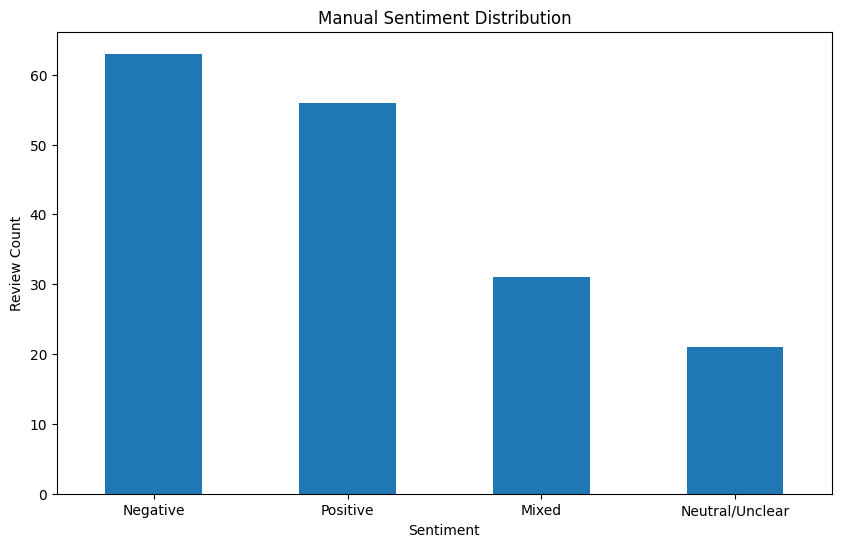

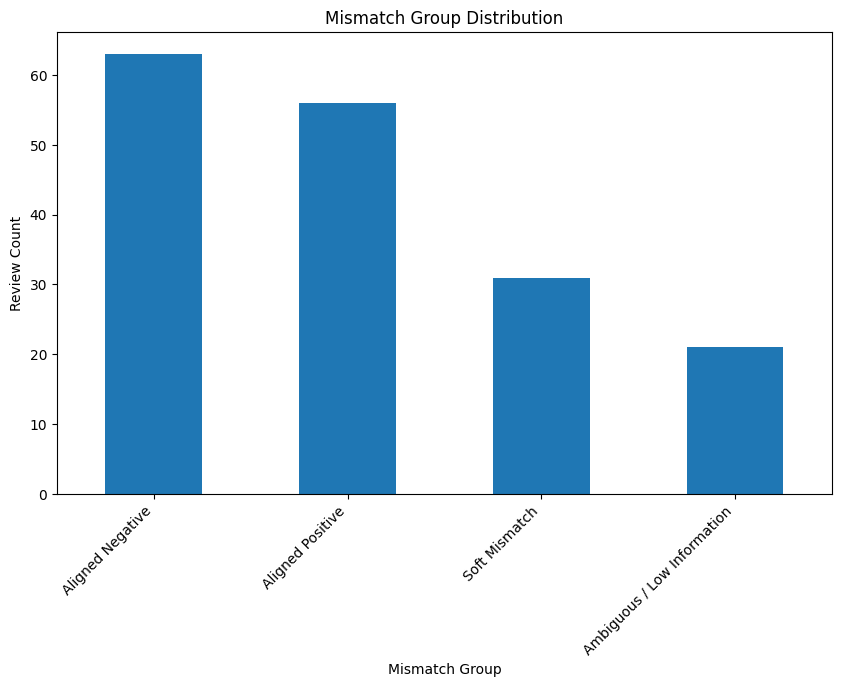

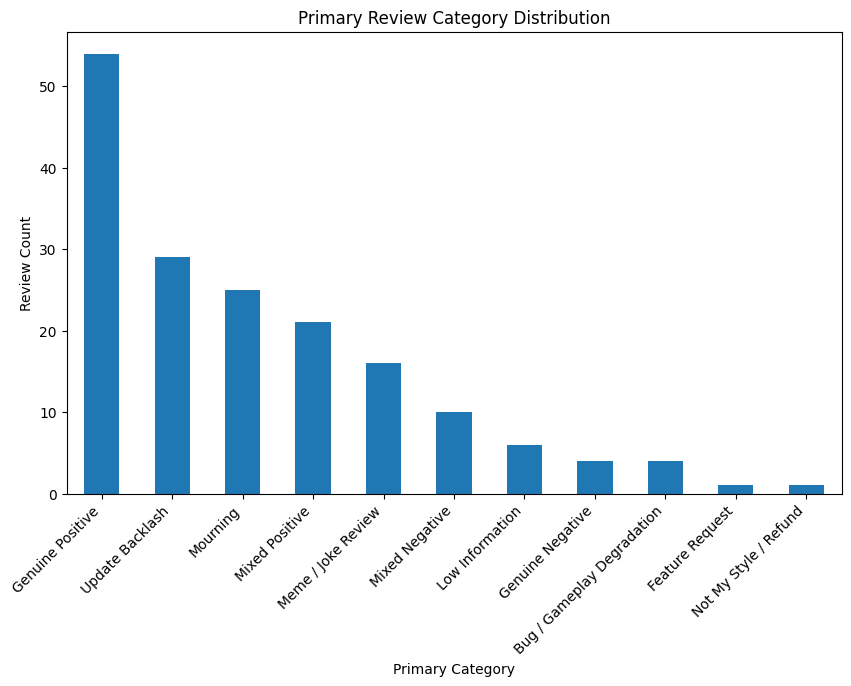

In [16]:
df["sentiment_group"].value_counts().plot(kind="bar")
plt.title("Manual Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.xticks(rotation=0)
plt.show()

df["mismatch_group"].value_counts().plot(kind="bar")
plt.title("Mismatch Group Distribution")
plt.xlabel("Mismatch Group")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.show()

df["primary_category"].value_counts().plot(kind="bar")
plt.title("Primary Review Category Distribution")
plt.xlabel("Primary Category")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.show()

## 16. Final Output Checklist

After running the notebook, the following files should be available:

```text
data/dashboard/dashboard_review_level.csv
data/dashboard/dashboard_kpi_summary.csv
data/dashboard/dashboard_recommendation_sentiment_matrix.csv
data/dashboard/dashboard_mismatch_summary.csv
data/dashboard/dashboard_mismatch_by_recommendation.csv
data/dashboard/dashboard_category_summary.csv
data/dashboard/dashboard_player_sentiment_summary.csv
data/dashboard/dashboard_player_mismatch_summary.csv
data/dashboard/dashboard_theme_summary.csv
data/dashboard/dashboard_theme_by_recommendation.csv
data/dashboard/dashboard_model_summary.csv
data/dashboard/dashboard_error_examples_clean.csv
data/dashboard/dashboard_representative_examples.csv
data/dashboard/README_dashboard_datasets.md
```

Final implementation step:

```text
Build the four dashboard pages in Tableau
```

Dashboard title:

```text
Understanding Sentiment Ambiguity in Steam Reviews
```